# SILVA Thermodynamically Informed Neural Operator

This lab derives a physical-strain equilibrium, verifies it on an exact
periodic elastic cell, exposes every replaceable component, and maps the compact
case to the source-scale mechanics protocol. The thermodynamic construction
follows TherINO [[73]](https://jseluis.github.io/silva-networks/paper/references/#ref-73); SILVA provides the common solver, transition, diagnostics,
scaling, and reproduction contracts.

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[31]](https://jseluis.github.io/silva-networks/paper/references/#ref-31), [[32]](https://jseluis.github.io/silva-networks/paper/references/#ref-32), [[73]](https://jseluis.github.io/silva-networks/paper/references/#ref-73). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(33)

from torch import nn
from silva_networks import (
    SILVATherINO,
    SILVAThermodynamicEncoder,
    SILVAThermodynamicUpdate,
    SolverConfig,
    make_therino_elastic_dataset,
)

## 1. Physical State, Constitutive Map, and Equilibrium

Let $arepsilon(x)\in\mathbb R^{d_s}$ be the strain components and
$C(x)\in\mathbb R^{d_s\times d_s}$ the local stiffness. Linear elasticity
gives

$$
\sigma(x)=C(x):\varepsilon(x),\qquad
W(x)=\frac12\varepsilon(x):\sigma(x).
$$

The prescribed loading is a volume average,

$$
\langle\varepsilon\rangle
=\frac{1}{|\Omega|}\int_\Omega\varepsilon(x)\,dx
=\bar\varepsilon.
$$

Instead of solving an unrelated latent state, the transition acts on the
physical strain itself. A fixed thermodynamic encoder forms

$$
q(\varepsilon,C,\bar\varepsilon)
=\left[\varepsilon,\ C:\varepsilon,\
\frac12\varepsilon:(C:\varepsilon),\ \bar\varepsilon\right],
$$

and the shared operator solves

$$
\varepsilon^\star
=\Pi_{\bar\varepsilon}
\left(U_\theta(q(\varepsilon^\star,C,\bar\varepsilon))\right).
$$

The projection
$\Pi_{\bar\varepsilon}(v)=v-\langle v\rangle+\bar\varepsilon$
enforces the macroscopic strain after every transition.

## 2. Exact Periodic Verification Cell

The compact dataset uses uncoupled diagonal elasticity. Mechanical equilibrium
requires constant stress in each component. With compliance
$S_i(x)=C_i(x)^{-1}$,

$$
\sigma_i=\frac{\bar\varepsilon_i}{\langle S_i\rangle},
\qquad
\varepsilon_i(x)=S_i(x)\sigma_i.
$$

This is a known solution, not a benchmark claim. It checks tensor layout,
constitutive contraction, bulk loading, the root solve, and all three losses
before expensive finite-element data are introduced.

In [3]:
data = make_therino_elastic_dataset(
    samples=4,
    size=24,
    strain_components=3,
    contrast=8.0,
    seed=73,
)
computed_stress = torch.einsum(
    "bijxy,bjxy->bixy", data.stiffness, data.target_strain
)
assert torch.allclose(computed_stress, data.target_stress, atol=1e-6)
assert torch.allclose(
    data.target_strain.mean(dim=(-2, -1)), data.macro_strain, atol=1e-7
)
print("stiffness:", tuple(data.stiffness.shape))
print("target strain:", tuple(data.target_strain.shape))
print("macroscopic strain:", data.macro_strain[0])

stiffness: (4, 3, 3, 24, 24)
target strain: (4, 3, 24, 24)
macroscopic strain: tensor([0.0523, 0.0555, 0.0546])


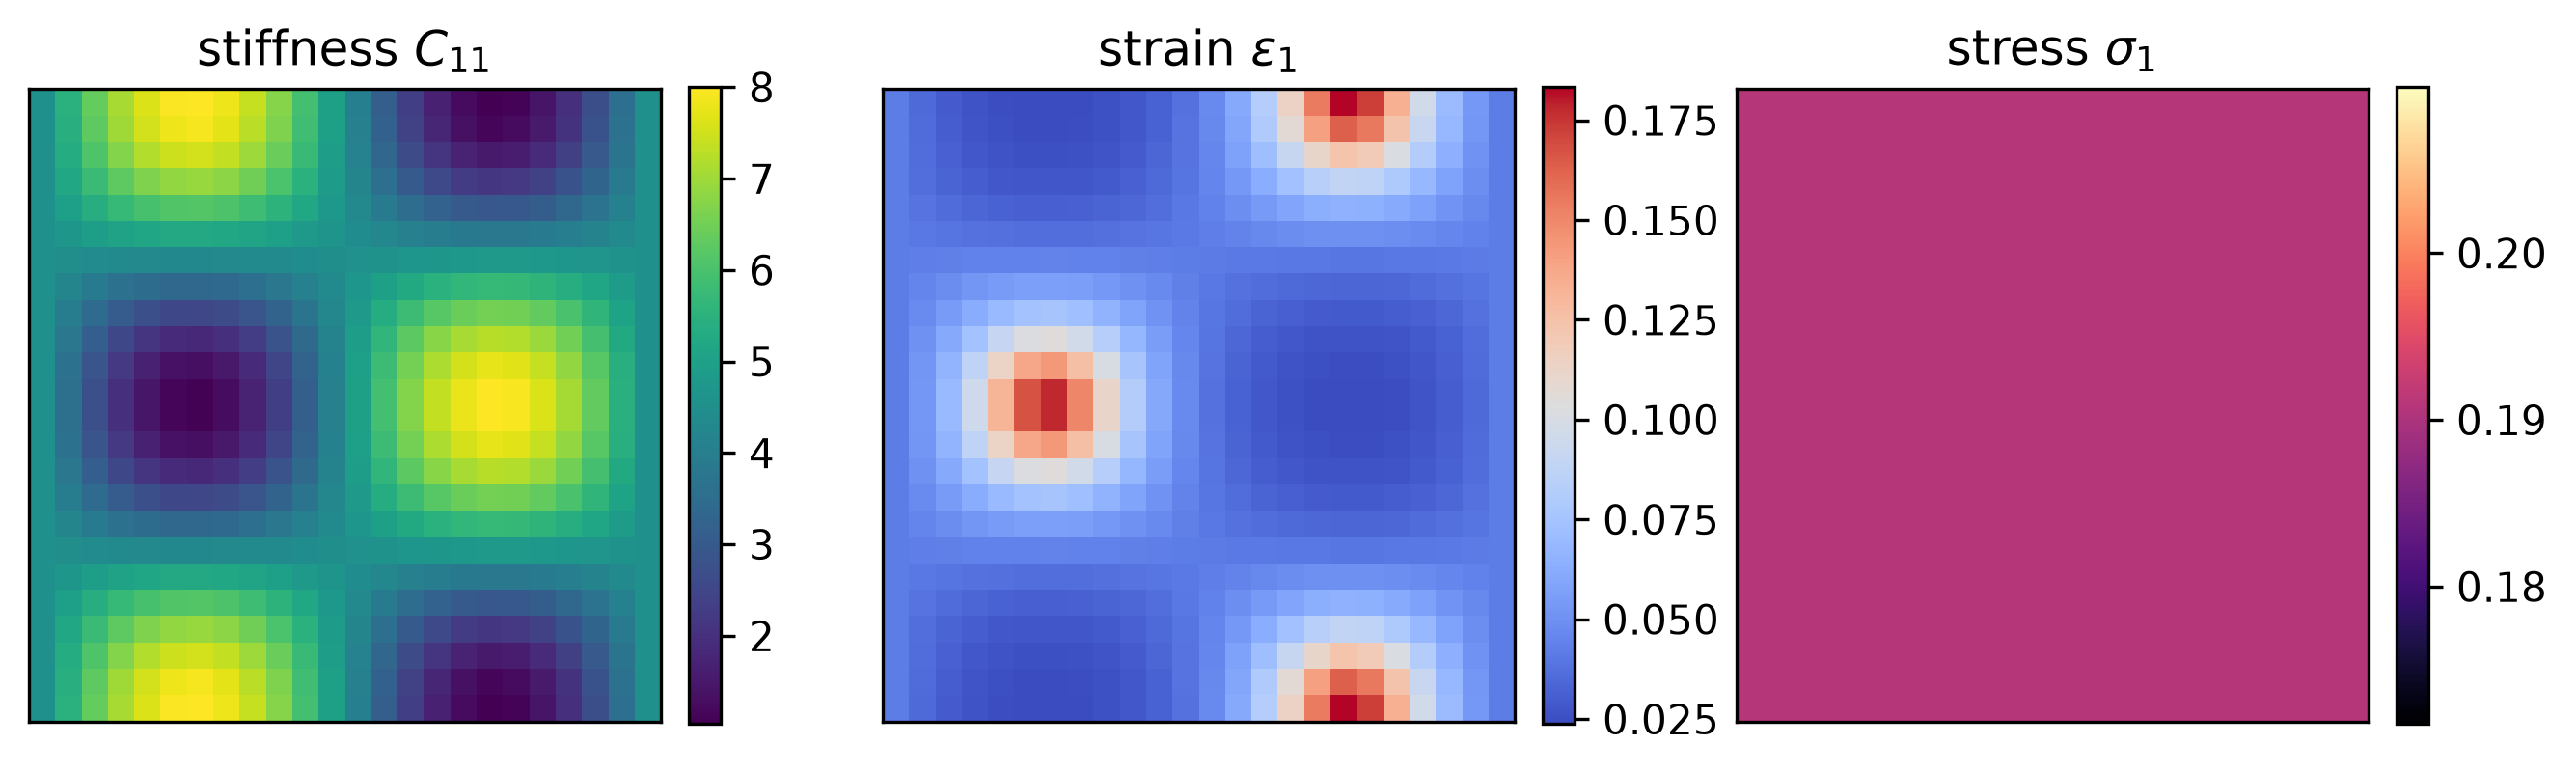

In [4]:
diagonal = torch.diagonal(
    data.stiffness[0], dim1=0, dim2=1
).permute(2, 0, 1)
figure, axes = plt.subplots(1, 3, figsize=(9.0, 2.7))
images = (
    axes[0].imshow(diagonal[0], cmap="viridis"),
    axes[1].imshow(data.target_strain[0, 0], cmap="coolwarm"),
    axes[2].imshow(data.target_stress[0, 0], cmap="magma"),
)
titles = (r"stiffness $C_{11}$", r"strain $\varepsilon_1$", r"stress $\sigma_1$")
for axis, image, title in zip(axes, images, titles):
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
plt.show()

## 3. Define What Lives Inside the SILVA Point

`SILVATherINO` separates five decisions:

| Role | Default | Replaceable contract |
|---|---|---|
| constitutive encoder | `SILVAThermodynamicEncoder` | `(strain, stiffness, macro) -> encoded field` |
| spatial update | Fourier point operator | `encoded field -> candidate strain` |
| loading constraint | mean-strain projection | candidate -> admissible candidate |
| equilibrium solver | Anderson | transition plus initial strain -> root |
| supervision | strain, stress, energy | result plus target -> scalar terms |

The exact relaxation below is intentionally transparent. It is a verification
operator whose fixed point is known. Replacing it with
`SILVAThermodynamicUpdate`, a U-Net, a convolutional hierarchy, or a custom
neural operator changes the internal architecture without changing the outer
SILVA contract.

In [5]:
class ExactMaterialRelaxation(nn.Module):
    def __init__(self, target, gain=0.35):
        super().__init__()
        self.register_buffer("target", target)
        self.gain = nn.Parameter(torch.tensor(gain))

    def forward(self, encoded):
        current_strain = encoded[:, : self.target.shape[1]]
        return self.gain * current_strain + (1.0 - self.gain) * self.target

update = ExactMaterialRelaxation(data.target_strain)
model = SILVATherINO(
    strain_components=3,
    encoder=SILVAThermodynamicEncoder(3),
    update=update,
    enforce_macro_strain=True,
    config=SolverConfig(
        solver="picard",
        max_iter=14,
        tol=1e-8,
        backward_mode="unrolled",
        anderson_batch_dims=1,
        return_best=False,
    ),
)
result = model(data.stiffness, data.macro_strain, return_result=True)
objective = model.loss(result, data.target_strain, data.stiffness)
assert torch.allclose(result.strain, data.target_strain, atol=2e-6)
print("iterations:", result.solver_result.iterations)
print("terminal residual:", result.solver_result.residual)
print("strain/stress/energy losses:",
      float(objective.strain), float(objective.stress), float(objective.energy))

iterations: 14
terminal residual: 1.0909918728430057e-06
strain/stress/energy losses: 1.9932516957642124e-16 2.7575839459386287e-15 4.420420106258878e-17


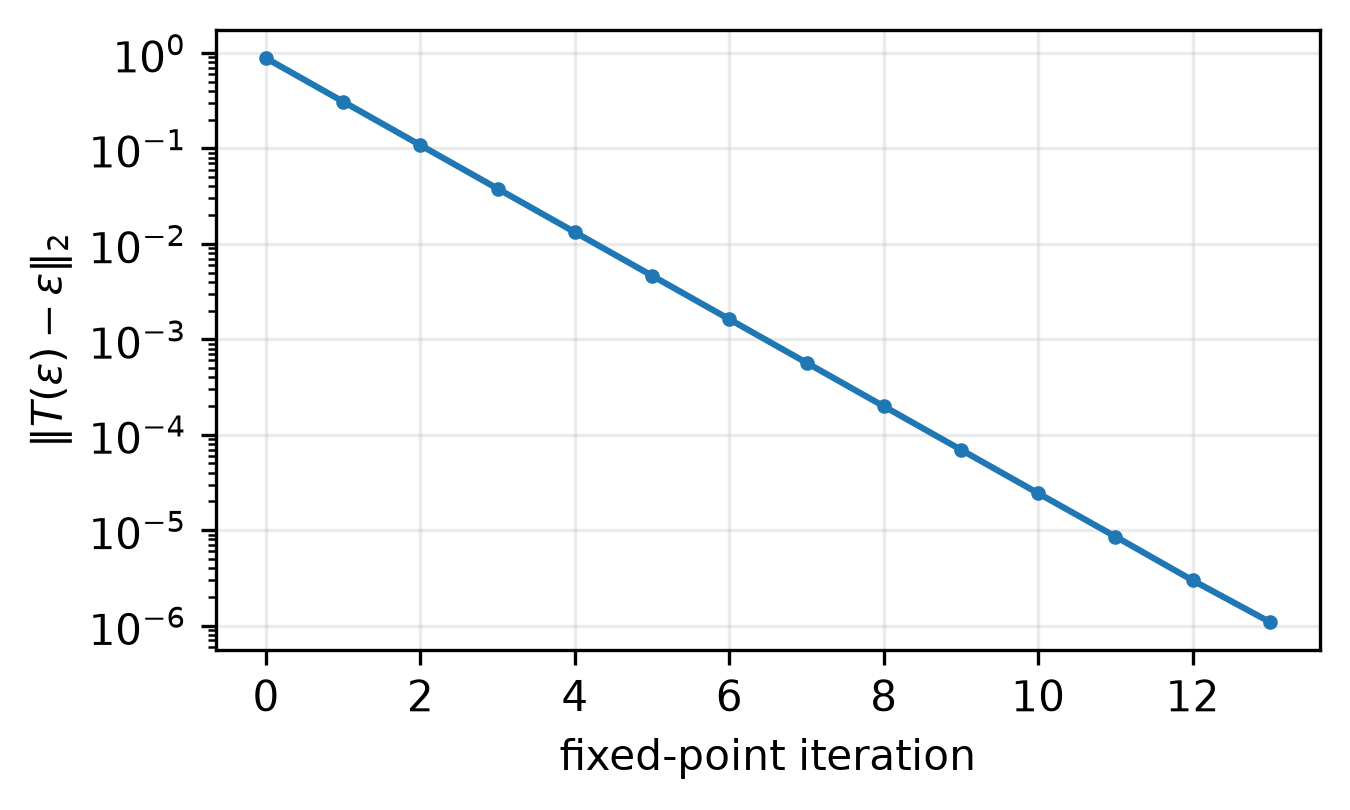

In [6]:
figure, axis = plt.subplots(figsize=(4.6, 2.8))
axis.semilogy(result.solver_result.residuals, marker="o", markersize=2.5)
axis.set(
    xlabel="fixed-point iteration",
    ylabel=r"$\|T(\varepsilon)-\varepsilon\|_2$",
)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## 4. Trainable Finite-Iteration Objective

For targets $(\varepsilon^{data},\sigma^{data},W^{data})$, the complete compact
objective is

$$
\mathcal L
=\lambda_\varepsilon\|\varepsilon^\star-\varepsilon^{data}\|_2^2
+\lambda_\sigma\|C:\varepsilon^\star-\sigma^{data}\|_2^2
+\lambda_W\|W(\varepsilon^\star)-W^{data}\|_2^2.
$$

The next cell deliberately uses only three unrolled iterations. The remaining
finite-iteration error gives a nonzero signal for the relaxation parameter and
demonstrates the complete gradient path.

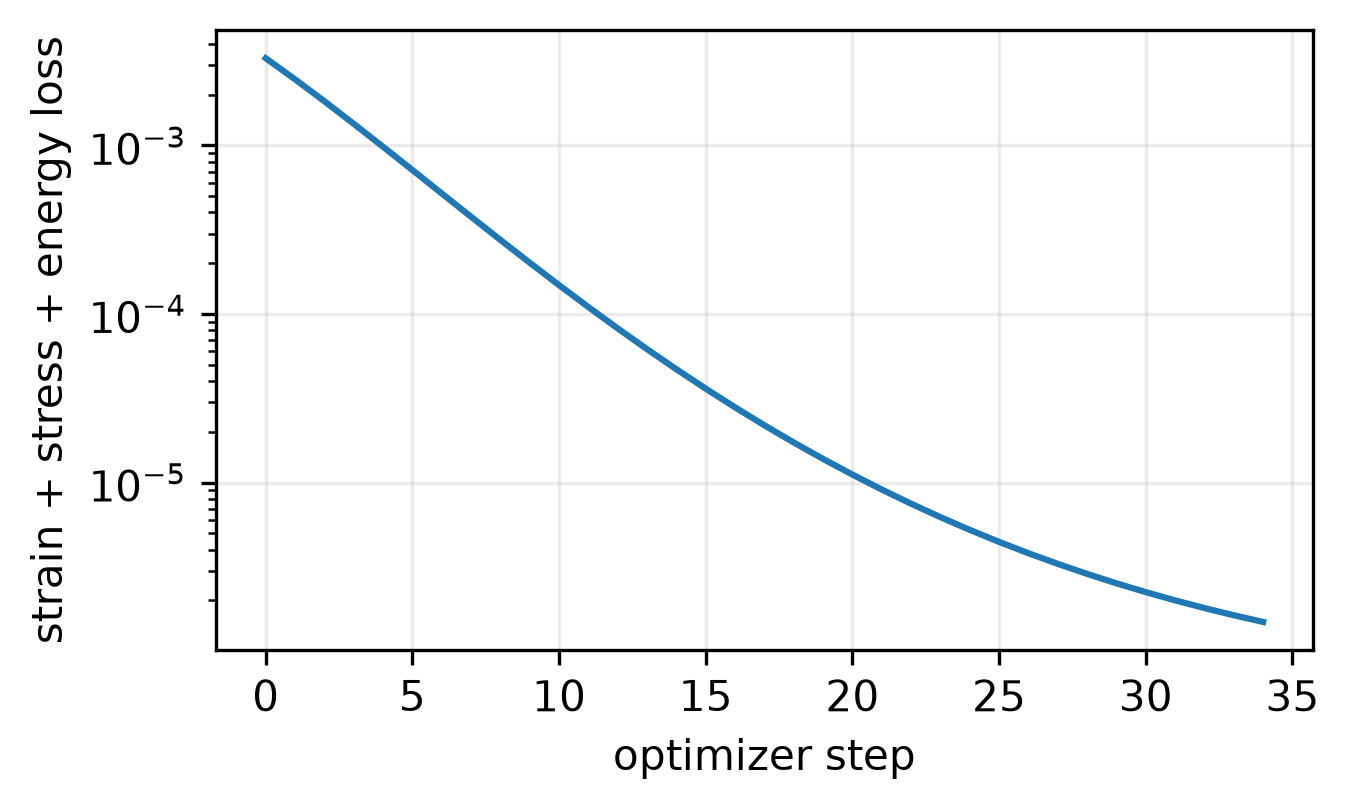

learned relaxation gain: 0.2320328950881958


In [7]:
train_update = ExactMaterialRelaxation(data.target_strain, gain=0.85)
train_model = SILVATherINO(
    update=train_update,
    config=SolverConfig(
        solver="picard", max_iter=3, tol=1e-12,
        backward_mode="unrolled", return_best=False
    ),
)
optimizer = torch.optim.Adam(train_model.parameters(), lr=4e-2)
losses = []
for _ in range(35):
    optimizer.zero_grad()
    prediction = train_model(data.stiffness, data.macro_strain, return_result=True)
    loss = train_model.loss(prediction, data.target_strain, data.stiffness)
    loss.total.backward()
    optimizer.step()
    losses.append(float(loss.total.detach()))

assert losses[-1] < losses[0]
figure, axis = plt.subplots(figsize=(4.6, 2.8))
axis.semilogy(losses)
axis.set(xlabel="optimizer step", ylabel="strain + stress + energy loss")
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()
print("learned relaxation gain:", float(train_update.gain.detach()))

## 5. Move from the Exact Cell to Full Mechanics

For a source-scale study [[73]](https://jseluis.github.io/silva-networks/paper/references/#ref-73), replace only the components demanded by the
physics:

1. Generate periodic two- or multi-phase microstructures and retain constituent
   stiffness tensors, geometry parameters, load cases, and seeds.
2. Produce strain and stress labels with a declared finite-element solver,
   discretization, tolerance, and periodic boundary construction.
3. Use the Fourier update below or provide another differentiable operator with
   the same shape contract.
4. Train strain, stress, and energy terms; report localization and homogenized
   response on held-out geometries, loadings, resolutions, and stiffness
   contrasts.
5. Record root residuals, iterations, wall time, memory, normalization, model
   width/modes, and every checkpoint revision.

The default operator is directly inspectable and can be replaced at
construction time:

In [8]:
full_update = SILVAThermodynamicUpdate(
    strain_components=3,
    hidden_channels=48,
    modes_height=12,
    modes_width=12,
    scale=0.12,
)
full_model = SILVATherINO(
    strain_components=3,
    update=full_update,
    config=SolverConfig(
        solver="anderson",
        max_iter=60,
        tol=1e-5,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
        return_best=True,
    ),
)
print(full_model.update)
print("trainable parameters:", sum(p.numel() for p in full_model.parameters()))

SILVAThermodynamicUpdate(
  (lift): Conv2d(10, 48, kernel_size=(1, 1), stride=(1, 1))
  (operator): SILVAFourierOperatorPointArchitecture(
    (spectral): _SpectralConv2d()
    (local): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
  )
  (project): Sequential(
    (0): GELU(approximate='none')
    (1): Conv2d(48, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)
trainable parameters: 1330131


## Interpretation Boundary

The compact cell verifies the SILVA implementation route and exact mechanics
identities. It does not reproduce the source paper's three-dimensional
microstructure corpus, finite-element labels, architecture scale, training
budget, or reported aggregate metrics. The final preflight cell lists those
requirements explicitly so a sufficiently provisioned reader can proceed
without changing the public interface.

## Source Data and Full Experiment Preflight

The source mechanics corpus [[73]](https://jseluis.github.io/silva-networks/paper/references/#ref-73) is generated from periodic microstructures and numerical localization solves. Validate 16-64 small two-dimensional cells first, then restore the three-dimensional geometry, constitutive contrast, loading, finite-element, split, normalization, Fourier-mode, and evaluation protocol.

The executable record below distinguishes public, generated, and licensed
inputs and keeps storage and launch steps next to the model contract. Compact
results validate the implementation route; the cited benchmark additionally
requires every recorded source-scale step.

In [9]:
from silva_networks import silva_reproduction_spec

source_plan = silva_reproduction_spec('silva_therino')
print("data sources:")
for source in source_plan.data_sources:
    print(" -", source)
print("access:")
for item in source_plan.data_access:
    print(" -", item)
print("storage:")
for item in source_plan.storage_plan:
    print(" -", item)
print("source-scale steps:")
for index, item in enumerate(source_plan.source_scale_steps, start=1):
    print(f" {index}. {item}")

data sources:
 - https://arxiv.org/abs/2411.06529
 - https://doi.org/10.1016/j.cma.2025.117939
access:
 - The source experiments use procedurally generated periodic microstructures and numerical mechanics labels rather than one packaged benchmark archive.
 - Record geometry generation, constituent stiffness tensors, periodic boundary conditions, load cases, finite-element discretization, and every split seed.
storage:
 - Dense mechanics bytes = samples * voxels * (material + strain + stress channels) * bytes per element.
 - Keep microstructures, stiffness tensors, finite-element strain/stress labels, normalization, and checkpoints in separate shards; three-dimensional labels usually dominate storage.
source-scale steps:
 1. Reproduce the source periodic microstructure generator, constituent laws, finite-element labels, load cases, split, and normalization before fitting the operator.
 2. Configure the physical-state transition with the reported three-dimensional Fourier update, macrosc

## From 34 Silva Therino Mechanics to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | a sampled solution field on a grid or mesh |
| Condition | coefficient, forcing, boundary, and coordinate fields |
| Repeated computation | a tied local/spectral/operator field with source reinjection |
| Required invariants | spatial shape, boundary conditions, and resolution semantics |
| Replaceable components | lifting map, spectral/local operator, physics field, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


### Replace Constitutive Encoding and the Physical-Space Update

```python
model = SILVATherINO(
    strain_components=strain_components,
    encoder=my_constitutive_encoder,
    update=my_shape_preserving_operator,
    enforce_macro_strain=True,
    config=solver_config,
)
```

The encoder may add stress, energy, phase, coordinate, or history channels.
The update may be Fourier, convolutional, U-Net, graph based, or another
operator, but it must return the same strain-field shape. A source-scale run
must preserve the paper's constitutive representation, periodic projection,
microstructure generation, finite-element labels, loading split, and all
strain, stress, energy, and equilibrium metrics.


In [10]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**solution error, PDE residual, boundary error, and fixed-point residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **resolution, retained modes, channels, domain size, and dataset size**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [11]:
notebook_reproduction_record = {
    "notebook": '34_silva_therino_mechanics.ipynb',
    "state": 'a sampled solution field on a grid or mesh',
    "condition": 'coefficient, forcing, boundary, and coordinate fields',
    "transition": 'a tied local/spectral/operator field with source reinjection',
    "invariants": 'spatial shape, boundary conditions, and resolution semantics',
    "compact_metric": 'solution error, PDE residual, boundary error, and fixed-point residual',
    "scale_axis": 'resolution, retained modes, channels, domain size, and dataset size',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '34_silva_therino_mechanics.ipynb',
 'state': 'a sampled solution field on a grid or mesh',
 'condition': 'coefficient, forcing, boundary, and coordinate fields',
 'transition': 'a tied local/spectral/operator field with source reinjection',
 'invariants': 'spatial shape, boundary conditions, and resolution semantics',
 'compact_metric': 'solution error, PDE residual, boundary error, and fixed-point residual',
 'scale_axis': 'resolution, retained modes, channels, domain size, and dataset size'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **operator feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **a sampled solution field on a grid or mesh**, and its repeated map,
**a tied local/spectral/operator field with source reinjection**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [12]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('operator feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


operator feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


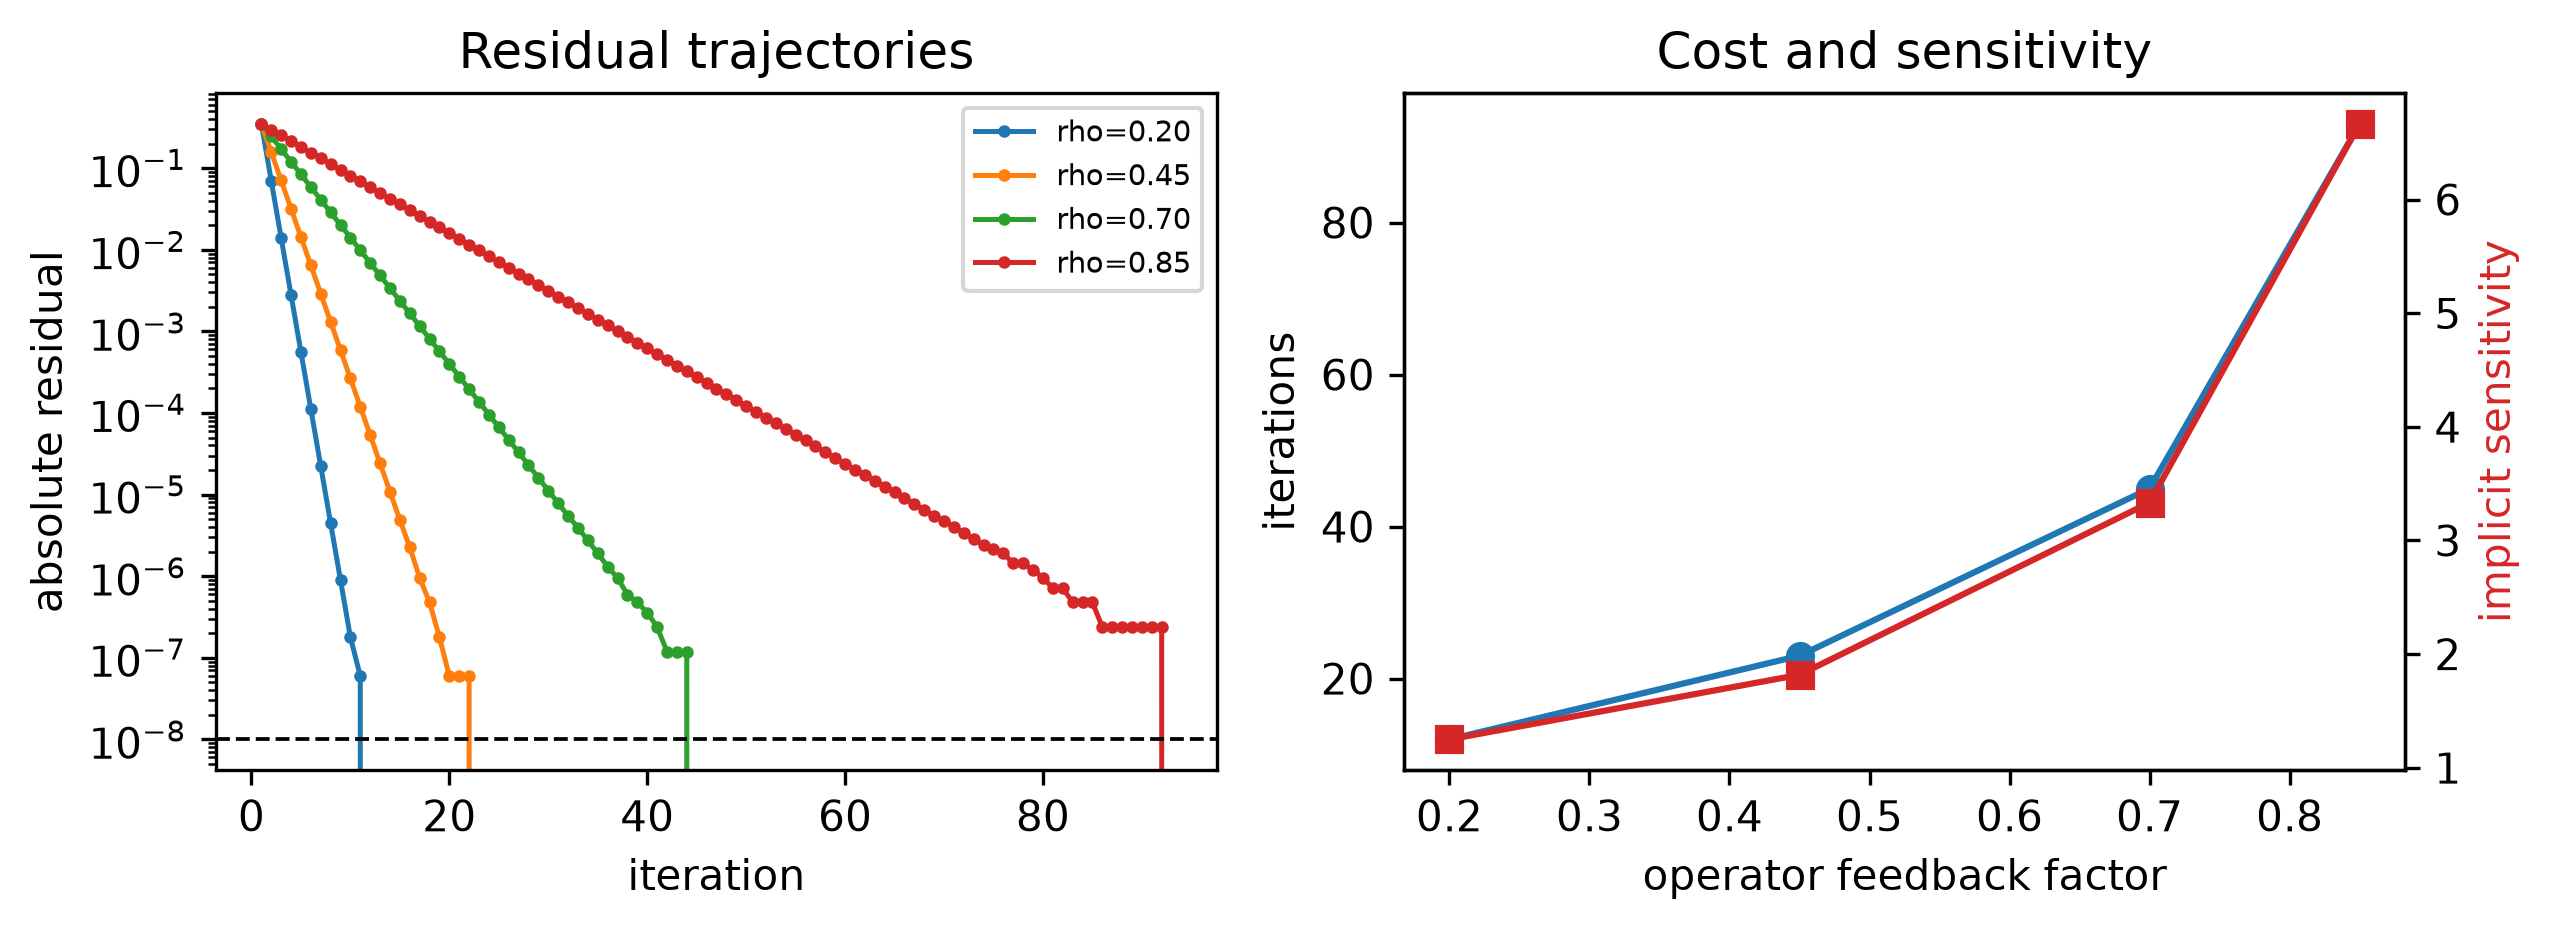

In [13]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('operator feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the operator feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | solution error, PDE residual, boundary error, and fixed-point residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | spatial shape, boundary conditions, and resolution semantics |
| Scale sweep | Change one of resolution, retained modes, channels, domain size, and dataset size at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is thermodynamic encoding solved in physical strain space? | [Emerging Equilibrium Methods](https://jseluis.github.io/silva-networks/learn/emerging-equilibrium-methods/#thermodynamically-informed-material-equilibria) |
| Which material encoder, operator, losses, and result records are public? | [Emerging Equilibria API](https://jseluis.github.io/silva-networks/api/emerging_equilibria/) |
| Which exact periodic cell verifies strain, stress, and energy? | [Emerging Data API](https://jseluis.github.io/silva-networks/api/emerging_data/) |
